# 03 — Disease Image Data Acquisition & EDA
### AgriVision AI — Disease Detection branch

Covers: PlantVillage download, stratified train/val split, class-balance chart, sample image grid.


## Kaggle setup

In [ ]:
!pip install kaggle -q
from google.colab import files
files.upload()   # upload kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


## Download PlantVillage

In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip -q plantvillage-dataset.zip -d plantvillage_raw
import os
raw_classes = sorted(os.listdir("plantvillage_raw"))
print(f"{len(raw_classes)} classes found:")
for c in raw_classes:
    print(" ", c)


Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:10<00:00, 202MB/s]

1 classes found:
  plantvillage dataset


**Checkpoint:** confirm class names start with `Potato`, `Corn_(maize)`, `Soybean` before continuing.

## (Optional) Mount Drive so raw data + outputs survive session resets

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import os

def show_tree(path, depth=0, max_depth=3):
    if depth > max_depth:
        return
    try:
        entries = sorted(os.listdir(path))
    except NotADirectoryError:
        return
    for e in entries[:10]:  # cap so it doesn't flood output
        print("  " * depth + e)
        show_tree(os.path.join(path, e), depth + 1, max_depth)

show_tree("plantvillage_raw")

plantvillage dataset
  color
    Apple___Apple_scab
      00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG
      01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG
      01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112.JPG
      0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Scab 3037.JPG
      023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Scab 3487.JPG
      0261a6e4-21f8-481a-8827-b674e6955644___FREC_Scab 3055.JPG
      029424b0-0ef5-491b-9ef5-069190d24d8f___FREC_Scab 3504.JPG
      03354abb-aa1c-4f9d-a1ef-9f40505cd539___FREC_Scab 3355.JPG
      0340dc35-5215-48ab-8db7-06af99fcb358___FREC_Scab 2966.JPG
      0395b847-2c73-4674-826f-33a6afb5b4fe___FREC_Scab 3287.JPG
    Apple___Black_rot
      0090d05d-d797-4c99-abd4-3b9cb323a5fd___JR_FrgE.S 8727.JPG
      00e909aa-e3ae-4558-9961-336bb0f35db3___JR_FrgE.S 8593.JPG
      0139bc6d-391c-4fd1-bcae-cc74dabfddd7___JR_FrgE.S 2734.JPG
      0199a733-6d3f-4e66-a903-2d1d34457871___JR_FrgE.S 3079.JPG
      01e94c43-0879-4e8c-9b61-

In [ ]:
import os
print("Top level:", os.listdir("plantvillage_raw"))
print(os.listdir("plantvillage_raw/plantvillage dataset"))


Top level: ['plantvillage dataset']
['grayscale', 'segmented', 'color']


## Stratified train/val split

In [ ]:
import os, random, shutil
import numpy as np
import matplotlib.pyplot as plt

RNG = 42
random.seed(RNG); np.random.seed(RNG)

RAW_DIR = "plantvillage_raw/plantvillage dataset/color"
SPLIT_DIR = "data/images"
OUT_FIG = "outputs/figures"
os.makedirs(OUT_FIG, exist_ok=True)

CROP_PREFIXES = ["Potato", "Corn_(maize)", "Soybean"]
MAX_PER_CLASS = 300

def make_stratified_split(raw_dir=RAW_DIR, split_dir=SPLIT_DIR,
                           crop_prefixes=CROP_PREFIXES, max_per_class=MAX_PER_CLASS, val_frac=0.2):
    class_dirs = [d for d in sorted(os.listdir(raw_dir)) if any(d.startswith(p) for p in crop_prefixes)]
    if not class_dirs:
        raise RuntimeError(f"No class folders matched {crop_prefixes}")
    print(f"Found {len(class_dirs)} matching classes: {class_dirs}")
    counts = {}
    for cls in class_dirs:
        src = os.path.join(raw_dir, cls)
        f_list = [f for f in os.listdir(src) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        random.shuffle(f_list)
        f_list = f_list[:max_per_class]
        n_val = max(1, int(len(f_list) * val_frac))
        val_f, train_f = f_list[:n_val], f_list[n_val:]
        for split_name, split_files in [("train", train_f), ("val", val_f)]:
            dst = os.path.join(split_dir, split_name, cls)
            os.makedirs(dst, exist_ok=True)
            for f in split_files:
                shutil.copy(os.path.join(src, f), os.path.join(dst, f))
        counts[cls] = {"train": len(train_f), "val": len(val_f)}
    return counts

counts = make_stratified_split()
for cls, c in counts.items():
    print(f"  {cls:<45} train={c['train']:4d}  val={c['val']:4d}")


Found 8 matching classes: ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Soybean___healthy']
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot train= 240  val=  60
  Corn_(maize)___Common_rust_                   train= 240  val=  60
  Corn_(maize)___Northern_Leaf_Blight           train= 240  val=  60
  Corn_(maize)___healthy                        train= 240  val=  60
  Potato___Early_blight                         train= 240  val=  60
  Potato___Late_blight                          train= 240  val=  60
  Potato___healthy                              train= 122  val=  30
  Soybean___healthy                             train= 240  val=  60


## EDA — class balance

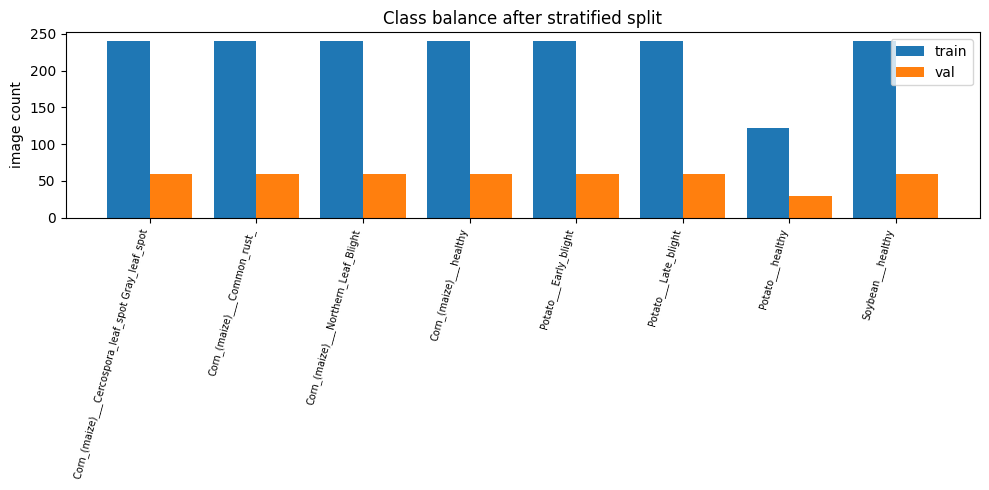

In [ ]:
labels = list(counts.keys())
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, [counts[c]["train"] for c in labels], width=0.4, label="train")
ax.bar(x + 0.2, [counts[c]["val"] for c in labels], width=0.4, label="val")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=75, ha="right", fontsize=7)
ax.set_ylabel("image count"); ax.set_title("Class balance after stratified split")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_FIG}/disease_class_balance.png", dpi=150)
plt.show()


## EDA — sample image grid (visual sanity check)

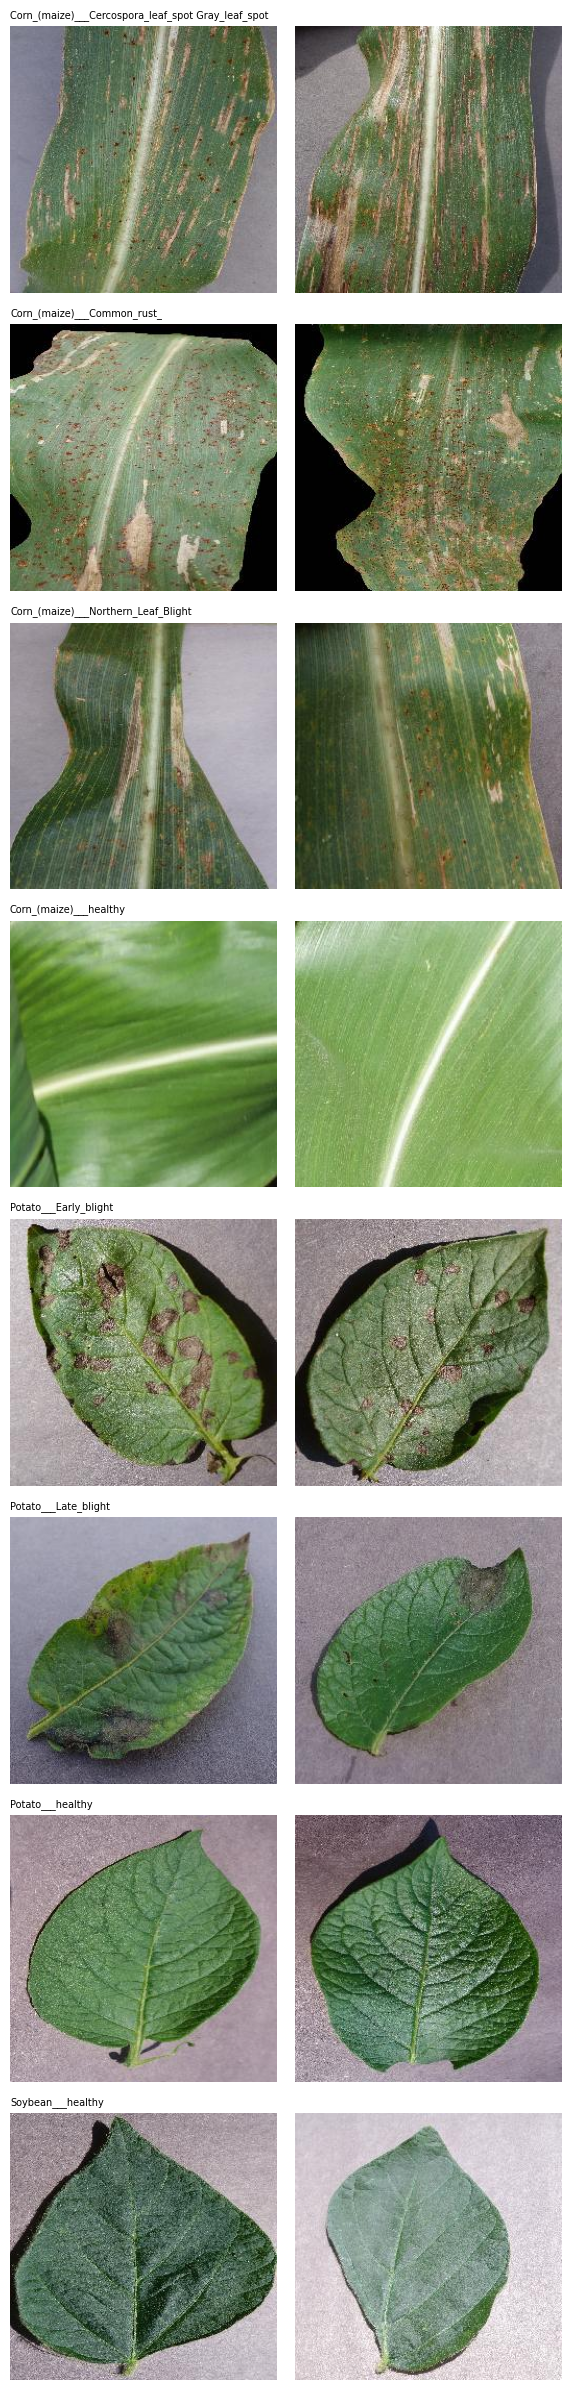

In [ ]:
import cv2

classes = sorted(os.listdir(os.path.join(SPLIT_DIR, "train")))
n_per_class = 2
fig, axes = plt.subplots(len(classes), n_per_class, figsize=(3 * n_per_class, 3 * len(classes)))
for i, cls in enumerate(classes):
    cls_dir = os.path.join(SPLIT_DIR, "train", cls)
    for j, f in enumerate(os.listdir(cls_dir)[:n_per_class]):
        img = cv2.cvtColor(cv2.imread(os.path.join(cls_dir, f)), cv2.COLOR_BGR2RGB)
        ax = axes[i, j] if len(classes) > 1 else axes[j]
        ax.imshow(img); ax.axis("off")
    axes[i, 0].set_title(cls, fontsize=7, loc="left")
plt.tight_layout()
plt.savefig(f"{OUT_FIG}/disease_sample_grid.png", dpi=150)
plt.show()


## Backup split + figures to Drive

In [ ]:
!cp -r data outputs /content/drive/MyDrive/agrivision/ 2>/dev/null || print("Skip if Drive not mounted")


/bin/bash: -c: line 1: syntax error near unexpected token `"Skip if Drive not mounted"'
/bin/bash: -c: line 1: `cp -r data outputs /content/drive/MyDrive/agrivision/ 2>/dev/null || print("Skip if Drive not mounted")'
